In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
# Load dataset
df = pd.read_csv(r"C:\Users\User\Desktop\DataSets\heart_disease_uci.csv")

# Display first 5 rows
print(df.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
print("\nMissing Values:")
print(df.isnull().sum())

# If missing values exist, fill with median
df.fillna(df.median(numeric_only=True), inplace=True)


Missing Values:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


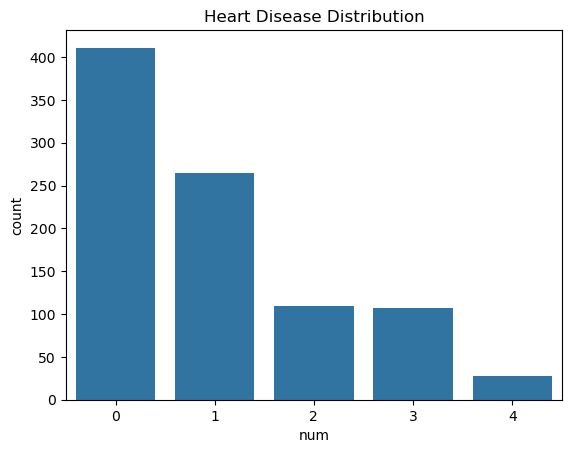

In [8]:
sns.countplot(x='num', data=df)
plt.title("Heart Disease Distribution")
plt.show()

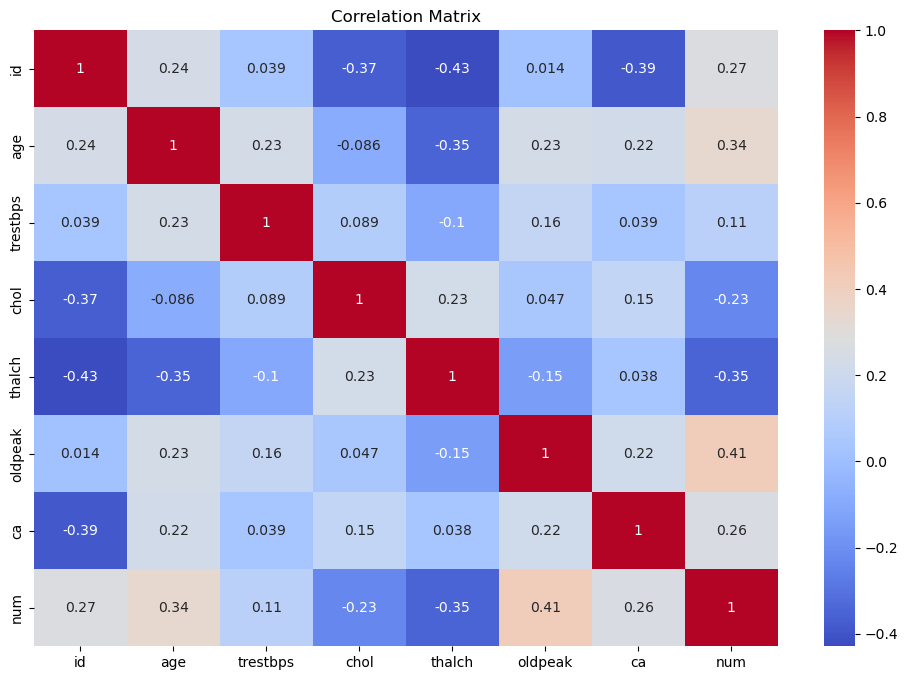

In [ ]:
#Correlation Matrix
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

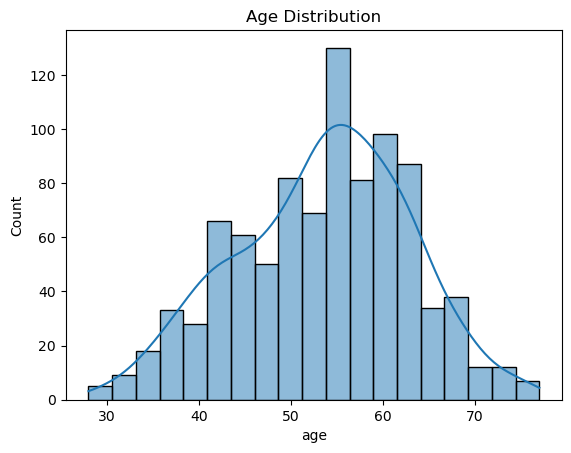

In [12]:
# Age Distribution
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

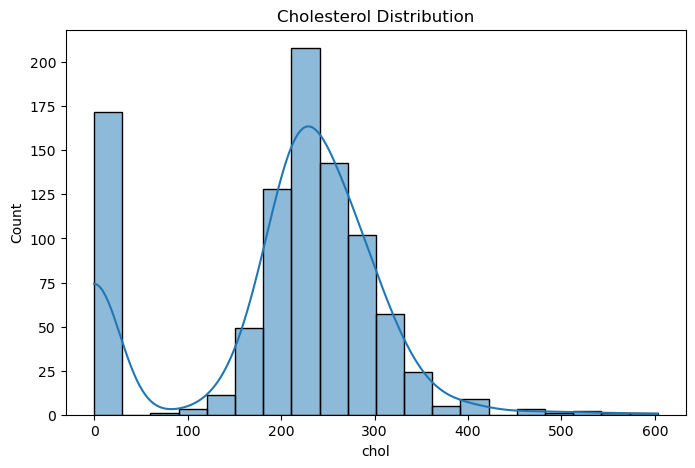

In [13]:
# Cholesterol Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['chol'], bins=20, kde=True)
plt.title("Cholesterol Distribution")
plt.show()


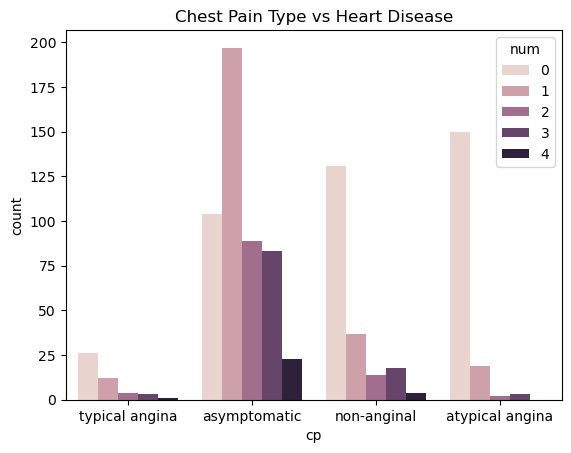

In [14]:
# Chest Pain Type vs Heart Disease
sns.countplot(x='cp', hue='num', data=df)
plt.title("Chest Pain Type vs Heart Disease")
plt.show()

In [23]:
X = df.drop('num', axis=1)
y = df['num']

# Convert text columns into numeric columns
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(920, 22)
   id  age  trestbps   chol  thalch  oldpeak   ca  sex_Male  dataset_Hungary  \
0   1   63     145.0  233.0   150.0      2.3  0.0      True            False   
1   2   67     160.0  286.0   108.0      1.5  3.0      True            False   
2   3   67     120.0  229.0   129.0      2.6  2.0      True            False   
3   4   37     130.0  250.0   187.0      3.5  0.0      True            False   
4   5   41     130.0  204.0   172.0      1.4  0.0     False            False   

   dataset_Switzerland  ...  cp_non-anginal  cp_typical angina  fbs_True  \
0                False  ...           False               True      True   
1                False  ...           False              False     False   
2                False  ...           False              False     False   
3                False  ...            True              False     False   
4                False  ...           False              False     False   

   restecg_normal  restecg_st-t abnormality  exang_T

In [24]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [25]:
# Scale numerical values for Logistic Regression
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [26]:
# Train Logistic Regression model
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [34]:
y_pred = model.predict(X_test)

# Probability predictions for ROC Curve
y_prob = model.predict_proba(X_test)[:, 1]


In [28]:
#Model Evaluation

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy Score:")
print(f"{accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy Score:
0.5543

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.87      0.76        75
           1       0.48      0.56      0.52        54
           2       0.22      0.08      0.12        25
           3       0.29      0.19      0.23        26
           4       0.00      0.00      0.00         4

    accuracy                           0.55       184
   macro avg       0.34      0.34      0.33       184
weighted avg       0.49      0.55      0.51       184



In [ ]:
# Feature Importance Analysis
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance)

                     Feature  Coefficient
8            dataset_Hungary     1.581038
10     dataset_VA Long Beach     0.953872
11        cp_atypical angina     0.708880
12            cp_non-anginal     0.347658
13         cp_typical angina     0.273284
20               thal_normal     0.203891
15            restecg_normal     0.156485
4                     thalch     0.126312
19           slope_upsloping     0.105630
1                        age     0.021515
16  restecg_st-t abnormality    -0.064706
14                  fbs_True    -0.065377
2                   trestbps    -0.105852
3                       chol    -0.154298
21    thal_reversable defect    -0.161090
9        dataset_Switzerland    -0.211466
18                slope_flat    -0.283402
17                exang_True    -0.301472
7                   sex_Male    -0.522240
6                         ca    -0.656700
5                    oldpeak    -0.677998
0                         id    -1.424887


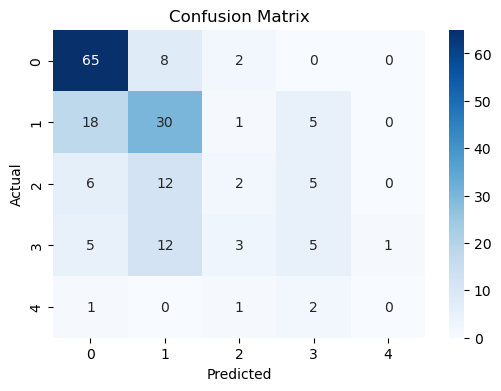

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
# Print the report 
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.87      0.76        75
           1       0.48      0.56      0.52        54
           2       0.22      0.08      0.12        25
           3       0.29      0.19      0.23        26
           4       0.00      0.00      0.00         4

    accuracy                           0.55       184
   macro avg       0.34      0.34      0.33       184
weighted avg       0.49      0.55      0.51       184



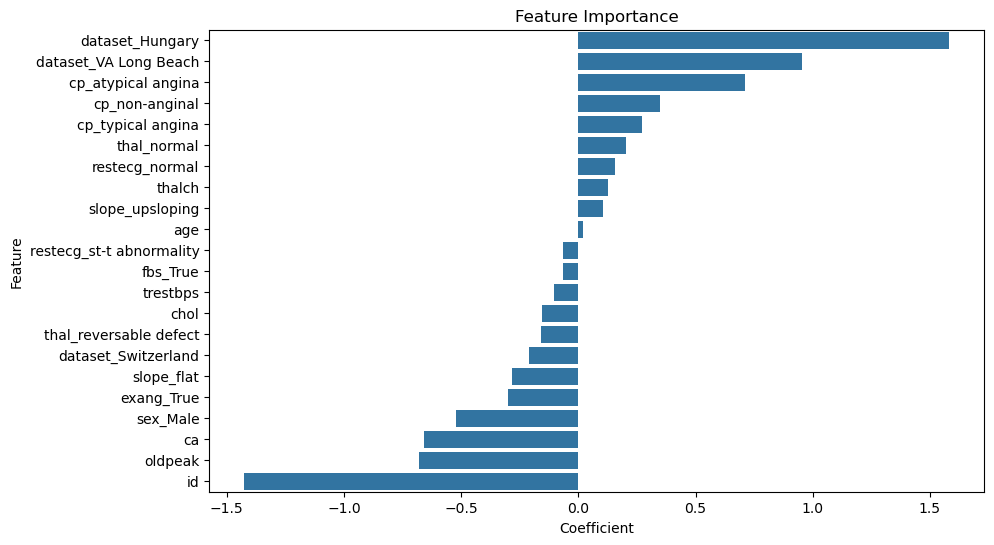

In [36]:
# Feature Importance Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [37]:

# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)   

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred_tree))

Accuracy: 0.5489130434782609


In [38]:
# Feature Importance for Decision Tree
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': tree.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                     Feature  Importance
0                         id    0.646703
6                         ca    0.172633
5                    oldpeak    0.057154
21    thal_reversable defect    0.050897
19           slope_upsloping    0.028110
7                   sex_Male    0.019272
2                   trestbps    0.016332
4                     thalch    0.008899
14                  fbs_True    0.000000
20               thal_normal    0.000000
18                slope_flat    0.000000
17                exang_True    0.000000
16  restecg_st-t abnormality    0.000000
15            restecg_normal    0.000000
13         cp_typical angina    0.000000
3                       chol    0.000000
12            cp_non-anginal    0.000000
1                        age    0.000000
10     dataset_VA Long Beach    0.000000
9        dataset_Switzerland    0.000000
8            dataset_Hungary    0.000000
11        cp_atypical angina    0.000000
